In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content
# 처음이면 clone, 이미 있으면 pull
!git clone https://github.com/chaeyoungwon/mask-aware-inpainting.git
# 또는
# !git checkout yeonholee
%cd mask-aware-inpainting


/content
Cloning into 'mask-aware-inpainting'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 185 (delta 6), reused 5 (delta 4), pack-reused 170 (from 1)
Receiving objects: 100% (185/185), 477.09 KiB | 15.39 MiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/mask-aware-inpainting


## 데이터셋 구성

In [3]:
# kaggle.json 업로드
from google.colab import files
files.upload()  # kaggle.json 선택

# 설치 및 인증
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
!kaggle datasets download -d jessicali9530/celeba-dataset -p ./mask-aware-inpainting/data/
!cd mask-aware-inpainting/data && unzip celeba-dataset.zip -d celeba_temp

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197604.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197605.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197606.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197607.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197608.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197609.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197610.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197611.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197612.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197613.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197614.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197615.jpg  
  inflating: celeba_temp/img_align_celeba/img_align_celeba/197616.jpg  
  inflating: celeba_temp/img

In [7]:
import os

# 이미지를 올바른 위치로 이동
src = '/content/mask-aware-inpainting/mask-aware-inpainting/data/celeba_temp/img_align_celeba/img_align_celeba'
dst = '/content/mask-aware-inpainting/data/celeba/img_align_celeba'

os.makedirs('/content/mask-aware-inpainting/data/celeba', exist_ok=True)
os.rename(src, dst)
print("완료:", len(os.listdir(dst)), "개")

base = '/content/mask-aware-inpainting/data/celeba'
filenames = sorted(os.listdir(f'{base}/img_align_celeba'))
n = len(filenames)

# list_eval_partition.txt
with open(f'{base}/list_eval_partition.txt', 'w') as f:
    for i, fname in enumerate(filenames):
        split = 0 if i < 162770 else (1 if i < 182637 else 2)
        f.write(f'{fname} {split}\n')

# identity
with open(f'{base}/identity_CelebA.txt', 'w') as f:
    for fname in filenames:
        f.write(f'{fname} 1\n')

# attr (더미)
attrs = ['5_o_Clock_Shadow','Arched_Eyebrows','Attractive','Bags_Under_Eyes','Bald','Bangs','Big_Lips','Big_Nose','Black_Hair','Blond_Hair','Blurry','Brown_Hair','Bushy_Eyebrows','Chubby','Double_Chin','Eyeglasses','Goatee','Gray_Hair','Heavy_Makeup','High_Cheekbones','Male','Mouth_Slightly_Open','Mustache','Narrow_Eyes','No_Beard','Oval_Face','Pale_Skin','Pointy_Nose','Receding_Hairline','Rosy_Cheeks','Sideburns','Smiling','Straight_Hair','Wavy_Hair','Wearing_Earrings','Wearing_Hat','Wearing_Lipstick','Wearing_Necklace','Wearing_Necktie','Young']
with open(f'{base}/list_attr_celeba.txt', 'w') as f:
    f.write(f'{n}\n{" ".join(attrs)}\n')
    for fname in filenames:
        f.write(fname + ' ' + ' '.join(['-1']*40) + '\n')

# bbox / landmarks (더미)
with open(f'{base}/list_bbox_celeba.txt', 'w') as f:
    f.write('image_id x_1 y_1 width height\n')
    for fname in filenames:
        f.write(f'{fname} 0 0 128 128\n')

with open(f'{base}/list_landmarks_align_celeba.txt', 'w') as f:
    f.write(f'{n}\nlefteye_x lefteye_y righteye_x righteye_y nose_x nose_y leftmouth_x leftmouth_y rightmouth_x rightmouth_y\n')
    for fname in filenames:
        f.write(f'{fname} 32 32 96 32 64 64 32 96 96 96\n')

print("메타파일 완료")
print(os.listdir(base))

완료: 202599 개
메타파일 완료
['list_eval_partition.txt', 'identity_CelebA.txt', 'list_bbox_celeba.txt', 'img_align_celeba', 'list_attr_celeba.txt', 'list_landmarks_align_celeba.txt']


In [8]:
# download=False 실제로 저장됐는지 확인
!grep "download" /content/mask-aware-inpainting/datasets/celeba_dataset.py

# 메타데이터 파일 있는지 확인
import os
celeba_dir = '/content/mask-aware-inpainting/data/celeba'
if os.path.exists(celeba_dir):
    print("celeba dir contents:", os.listdir(celeba_dir))
else:
    print("celeba dir does NOT exist!")

    root        : dataset root (CelebA will be downloaded here if needed)
            celeba = CelebA(root=root, split=split, transform=transform, download=False)
celeba dir contents: ['list_eval_partition.txt', 'identity_CelebA.txt', 'list_bbox_celeba.txt', 'img_align_celeba', 'list_attr_celeba.txt', 'list_landmarks_align_celeba.txt']


In [9]:
# 이미지가 어디 있는지 확인
import glob

paths_to_check = [
    '/content/mask-aware-inpainting/data/celeba/img_align_celeba',
    '/content/mask-aware-inpainting/data/celeba/img_align_celeba/img_align_celeba',
    '/content/mask-aware-inpainting/mask-aware-inpainting/data/celeba/img_align_celeba',
]
for p in paths_to_check:
    if os.path.exists(p):
        files = os.listdir(p)
        print(f"✅ {p}: {len(files)} files  (e.g. {files[:3]})")
    else:
        print(f"❌ {p}: not found")

✅ /content/mask-aware-inpainting/data/celeba/img_align_celeba: 202599 files  (e.g. ['139945.jpg', '089570.jpg', '034660.jpg'])
❌ /content/mask-aware-inpainting/data/celeba/img_align_celeba/img_align_celeba: not found
❌ /content/mask-aware-inpainting/mask-aware-inpainting/data/celeba/img_align_celeba: not found


In [10]:
import sys, importlib
sys.path.insert(0, '/content/mask-aware-inpainting')
%cd /content/mask-aware-inpainting

import datasets.celeba_dataset as celeba_dataset
importlib.reload(celeba_dataset)

CelebAInpaintingDataset = celeba_dataset.CelebAInpaintingDataset

/content/mask-aware-inpainting


In [11]:
from datasets.celeba_dataset import CelebAInpaintingDataset

In [12]:
from config import Config
import random, os
import numpy as np
import torch

random.seed(42); np.random.seed(42); torch.manual_seed(42)
cfg = Config()

dataset = CelebAInpaintingDataset(
    root=cfg.data_root,
    split='test',
    image_size=cfg.image_size,
    max_samples=500
)

print(f"Dataset size: {len(dataset)}")

Dataset size: 500


In [13]:
!python3 prepare_fixed_testset.py

Saving 500 samples to ./fixed_testset/  (seed=42) ...
  100/500
  200/500
  300/500
  400/500
  500/500

Saved 500 samples → ./fixed_testset/
Hole ratio — mean: 0.499 | min: 0.018 | max: 0.874
  small  (< 0.3)      : 108 samples
  medium (0.3 – 0.5)  : 125 samples
  large  (0.5 – 0.7)  : 158 samples


In [14]:
# conv_type을 'vanilla'으로 설정
import re
with open('config.py', 'r') as f:
    _cfg = f.read()
_cfg = re.sub(r"conv_type\s*=\s*'[^']*'", "conv_type = 'vanilla'", _cfg)
with open('config.py', 'w') as f:
    f.write(_cfg)
print("conv_type set to 'vanilla'")


conv_type set to 'vanilla'


## 학습

In [15]:
!python3 train.py

device: cuda  |  conv_type: vanilla  |  seed: 42
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:03<00:00, 176MB/s]
Trainable parameters: 4,511,011
  [1/30] step    0 | loss 2.5892 | valid 0.3485 | hole 0.2968 | perc 9.1939
  [1/30] step   20 | loss 1.4036 | valid 0.1190 | hole 0.1597 | perc 6.5327
  [1/30] step   40 | loss 1.2324 | valid 0.0935 | hole 0.1400 | perc 5.9809
  [1/30] step   60 | loss 1.1003 | valid 0.0692 | hole 0.1248 | perc 5.6529
  [1/30] step   80 | loss 1.1241 | valid 0.0923 | hole 0.1227 | perc 5.9072
  [1/30] step  100 | loss 1.1660 | valid 0.0524 | hole 0.1358 | perc 5.9754
  [1/30] step  120 | loss 1.0349 | valid 0.0518 | hole 0.1183 | perc 5.4620
  [1/30] step  140 | loss 0.9953 | valid 0.0620 | hole 0.1128 | perc 5.1334
[Epoch   1/30] train_loss: 1.2040 | val_loss: 1.1978 | val_PSNR: 9.76 | val_SSIM: 0.4963 | lr: 2.00e-04
  → Best model saved  (val_PSNR: 9.76)
  [

In [16]:
!python evaluate.py checkpoints/vanilla/best_model.pth --conv_type vanilla --fixed_testset ./fixed_testset


device: cuda  |  conv_type: vanilla
checkpoint: checkpoints/vanilla/best_model.pth
Fixed testset: ./fixed_testset
Trainable parameters: 4,511,011
Sample grid saved → checkpoints/vanilla/eval_vanilla_sample.png

────────────────────────────────────────────────────────
  Model      : vanilla   (4,511,011 params)
  Batches    : 16.0
────────────────────────────────────────────────────────
  Full-image PSNR  : 14.91 dB
  Full-image SSIM  : 0.7285
  Hole-only  PSNR  : 11.98 dB
  Hole-only  L1    : 0.1470
────────────────────────────────────────────────────────
  Per-bucket (hole ratio):
    small   (0.1–0.3) | n= 108 | PSNR=22.81 | hole_PSNR=15.58 | SSIM=0.9045
    medium  (0.3–0.5) | n= 125 | PSNR=17.17 | hole_PSNR=13.55 | SSIM=0.7843
    large   (0.5–0.7) | n= 267 | PSNR=13.97 | hole_PSNR=12.27 | SSIM=0.6316
────────────────────────────────────────────────────────
  CSV saved  → checkpoints/vanilla/eval_results_vanilla.csv
────────────────────────────────────────────────────────



## 시각화

/tmp/ipykernel_466/2544657641.py:17: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


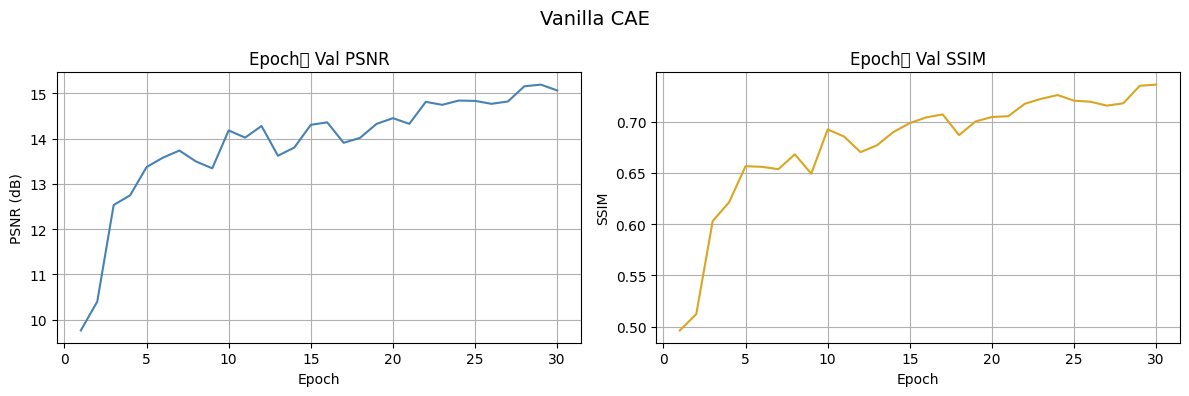

최종 PSNR: 15.07 dB  |  최종 SSIM: 0.7361


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('checkpoints/vanilla/training_history_vanilla.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Vanilla CAE', fontsize=14)

ax1.plot(df['epoch'], df['val_psnr'], color='steelblue')
ax1.set_title('Epoch별 Val PSNR')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('PSNR (dB)'); ax1.grid(True)

ax2.plot(df['epoch'], df['val_ssim'], color='goldenrod')
ax2.set_title('Epoch별 Val SSIM')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('SSIM'); ax2.grid(True)

plt.tight_layout()
plt.show()
print(f'최종 PSNR: {df["val_psnr"].iloc[-1]:.2f} dB  |  최종 SSIM: {df["val_ssim"].iloc[-1]:.4f}')
